# CPI 순수 미래 예측

이 노트북은 **과거 CPI 데이터만 사용**하여 미래 CPI를 예측합니다.

기존 노트북(forecast_single_timeseries)과 달리 **백테스트 없이 순수 미래 예측**만 수행합니다.

### 작동 방식
1. 과거 CPI 데이터를 모두 읽어서 모델에 입력
2. BISTRO 모델이 미래 N개월을 확률적으로 예측
3. 예측 결과(중앙값 + 신뢰구간)를 표와 그래프로 출력

## 1단계 - 환경 설정

In [ ]:
import os
import sys
from pathlib import Path

# Google Colab 환경인 경우
if 'google.colab' in sys.modules:
    os.chdir('/content/bistro/script')

repo_root = Path(os.path.join('..')).resolve()
src_root = Path(os.path.join('..', 'src')).resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print(f'프로젝트 루트: {repo_root}')
print(f'소스 경로: {src_root}')

프로젝트 루트: C:\Users\sam_s\OneDrive\문서\VS_sidePJ\bistro
소스 경로: C:\Users\sam_s\OneDrive\문서\VS_sidePJ\bistro\src


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from preprocessing_util import (
    detect_and_impute_gaps,
    forward_fill_to_daily,
    pad_future_markers,
)

print('라이브러리 로딩 완료')

라이브러리 로딩 완료


## 2단계 - 설정값

아래 값을 원하는 대로 수정하세요:
- `PDT`: 몇 개월 앞을 예측할지 (기본: 12개월)
- `CTX`: 과거 몇 개월을 참고할지 (기본: 240개월 = 20년)
- `CSV_PATH`: CPI 데이터 파일 경로

In [ ]:
# ============================================================
# 여기를 수정하세요
# ============================================================

CSV_PATH = repo_root / 'data' / 'bis_cpi_us_yoy_m.csv'  # CPI 데이터 파일
PDT = 6       # 예측 기간 (개월)
CTX = 240      # 과거 참고 기간 (개월)
PSZ = 32       # 패치 크기 (모델 기본값, 변경 불필요)
BSZ = 32       # 배치 크기
NUM_SAMPLES = 100  # 샘플 수 (많을수록 신뢰구간이 안정적)

MODEL_REPO = repo_root / 'bistro-finetuned'
FREQ = 'M'

## 3단계 - 데이터 로딩 및 전처리

CSV 파일을 읽고, 모델이 이해할 수 있는 일간(daily) 형식으로 변환합니다.

In [ ]:
# CSV 로딩
df = pd.read_csv(CSV_PATH, index_col=0)
df.index = pd.to_datetime(df.index)
target_col = df.columns[0]

print(f'변수명: {target_col}')
print(f'기간: {df.index[0].strftime("%Y-%m")} ~ {df.index[-1].strftime("%Y-%m")}')
print(f'데이터 수: {len(df)}개월')
print(f'\n최근 5개월:')
df.tail()

변수명: BIS_LONG_CPI:M:US:771
기간: 1914-01 ~ 2025-12
데이터 수: 1344개월

최근 5개월:


,BIS_LONG_CPI:M:US:771
2025-08-01,2.916174
2025-09-01,3.012677
2025-10-01,NaN
2025-11-01,2.735084
2025-12-01,2.677081


In [ ]:
# 결측치 보간
df_clean = detect_and_impute_gaps(df, freq=FREQ)

# 미래 구간에 더미값 추가 (모델이 예측할 영역)
df_padded = pad_future_markers(df_clean, target_col=target_col, n_pad_periods=PDT, freq=FREQ)

# 월간 → 일간 변환 (모델 입력 형식)
df_daily = forward_fill_to_daily(df_padded, patch_size_days=PSZ)

# 실제 데이터의 마지막 날짜 (이 시점까지가 context)
last_real_date = df_clean.index[-1]
cutoff_period = pd.Period(last_real_date, freq='D')

print(f'실제 데이터 마지막: {last_real_date.strftime("%Y-%m")}')
print(f'예측 시작: {last_real_date.strftime("%Y-%m")} 이후 {PDT}개월')

Index timestamps are not aligned to M period ends (max snap=30 days > tolerance_days=10).


실제 데이터 마지막: 2025-12
예측 시작: 2025-12 이후 6개월


## 4단계 - 모델 로딩 및 예측 실행

In [ ]:
pdt_steps = PSZ * PDT
ctx_steps = PSZ * CTX

# 데이터셋 생성 및 분할
ds = PandasDataset(df_daily, target=target_col)
train, test_template = split(ds, date=cutoff_period)

test_data = test_template.generate_instances(
    prediction_length=pdt_steps,
    windows=1,
    distance=1,
    max_history=ctx_steps,
)

print('데이터 준비 완료')

데이터 준비 완료


In [ ]:
# BISTRO 모델 로딩
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=pdt_steps,
    context_length=ctx_steps,
    patch_size=PSZ,
    num_samples=NUM_SAMPLES,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

print('모델 로딩 완료')

Loading weights from local directory
모델 로딩 완료


In [ ]:
# 예측 실행
predictor = model.create_predictor(batch_size=BSZ)
forecasts = list(predictor.predict(test_data.input))

print(f'예측 완료 (샘플 수: {forecasts[0].samples.shape[0]})')

예측 완료 (샘플 수: 100)


## 5단계 - 결과 정리

일간 예측을 월간으로 집계하고, 중앙값과 90% 신뢰구간을 계산합니다.

In [ ]:
samples = np.asarray(forecasts[0].samples, dtype=float)  # (NUM_SAMPLES, pdt_steps)

# 일간 샘플을 월 단위로 집계
monthly_preds = []
monthly_lo = []
monthly_hi = []

for m in range(PDT):
    start_idx = m * PSZ
    end_idx = (m + 1) * PSZ
    month_samples = samples[:, start_idx:end_idx].mean(axis=1)  # 각 샘플의 월 평균
    monthly_preds.append(float(np.median(month_samples)))
    monthly_lo.append(float(np.quantile(month_samples, 0.05)))
    monthly_hi.append(float(np.quantile(month_samples, 0.95)))

# 예측 기간 인덱스 생성
last_period = pd.Period(last_real_date, freq=FREQ)
forecast_index = pd.period_range(start=last_period + 1, periods=PDT, freq=FREQ)

df_forecast = pd.DataFrame({
    '예측값 (중앙값)': monthly_preds,
    '하한 (5%)': monthly_lo,
    '상한 (95%)': monthly_hi,
}, index=forecast_index)

print(f'=== {target_col} 미래 {PDT}개월 예측 ===')
print()
df_forecast

=== BIS_LONG_CPI:M:US:771 미래 6개월 예측 ===



,예측값 (중앙값),하한 (5%),상한 (95%)
2026-01,2.649356,2.437402,2.830041
2026-02,2.629098,2.429516,2.833672
2026-03,2.655611,2.474917,2.889180
2026-04,2.652054,2.452203,2.881274
2026-05,2.610643,2.392753,2.872673
2026-06,2.538885,2.330899,2.866258


## 6단계 - 시각화

과거 데이터와 미래 예측을 하나의 그래프로 보여줍니다.

C:\Users\sam_s\AppData\Local\Temp\ipykernel_38552\1952865662.py:34: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_dir / 'forecast_single_cpi.png', dpi=150, bbox_inches='tight')
C:\Users\sam_s\AppData\Local\Temp\ipykernel_38552\1952865662.py:34: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_dir / 'forecast_single_cpi.png', dpi=150, bbox_inches='tight')
C:\Users\sam_s\AppData\Local\Temp\ipykernel_38552\1952865662.py:34: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_dir / 'forecast_single_cpi.png', dpi=150, bbox_inches='tight')
C:\Users\sam_s\AppData\Local\Temp\ipykernel_38552\1952865662.py:34: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.savefig(fig_dir / 'forecast_single_cpi.png', dpi=150, bbox_inches='tight')
C:\Users\sam_s\AppData\Local\Temp\ipykernel_38552\1952865662.py:34:

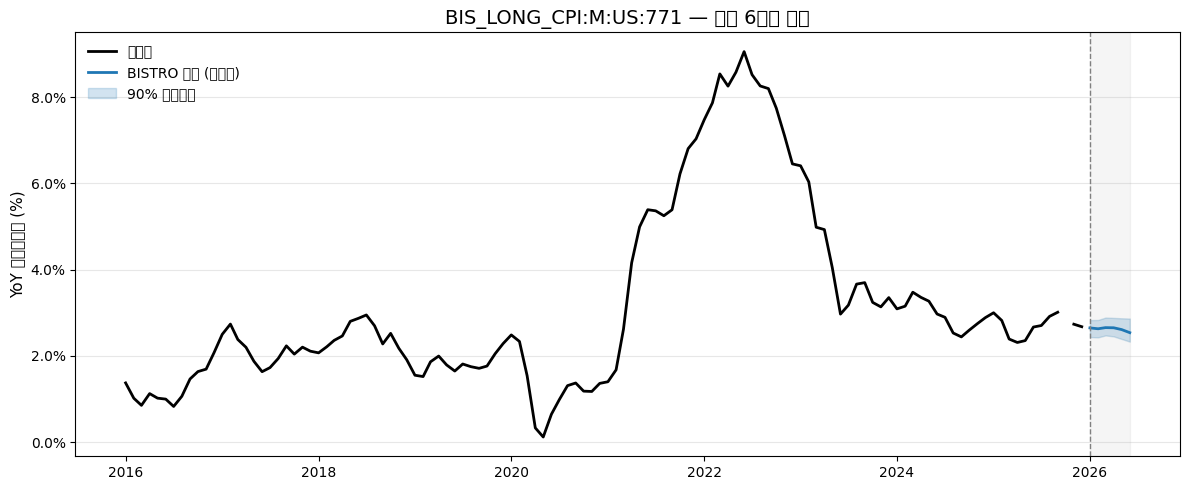


그래프 저장: C:\Users\sam_s\OneDrive\문서\VS_sidePJ\bistro\script\figures\forecast_single_cpi.png


In [ ]:
# 과거 데이터 (최근 120개월 = 10년만 표시)
DISPLAY_HISTORY = 120

df_monthly = df_clean.copy()
df_monthly.index = df_monthly.index.to_period(FREQ)
df_history = df_monthly.tail(DISPLAY_HISTORY)

# 그래프
fig, ax = plt.subplots(figsize=(12, 5))

# 과거 실제값
hist_x = df_history.index.to_timestamp()
ax.plot(hist_x, df_history[target_col].values, color='black', lw=2, label='실제값')

# 미래 예측값
fc_x = forecast_index.to_timestamp()
ax.plot(fc_x, monthly_preds, color='#1f77b4', lw=2, label='BISTRO 예측 (중앙값)')
ax.fill_between(fc_x, monthly_lo, monthly_hi, color='#1f77b4', alpha=0.2, label='90% 신뢰구간')

# 예측 시작 표시
fc_start = forecast_index[0].to_timestamp()
ax.axvline(fc_start, color='gray', ls='--', lw=1)
ax.axvspan(fc_start, fc_x[-1], color='gray', alpha=0.08)

ax.set_title(f'{target_col} — 미래 {PDT}개월 예측', fontsize=14)
ax.set_ylabel('YoY 인플레이션 (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100.0))
ax.legend(loc='upper left', frameon=False)
ax.grid(True, axis='y', alpha=0.3)

# 저장
fig_dir = repo_root / 'script' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'forecast_single_cpi.png', dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

print(f'\n그래프 저장: {fig_dir / "forecast_single_cpi.png"}')

## 7단계 - 엑셀 저장

예측 결과를 엑셀 파일로 저장하고 표로 확인합니다.

In [ ]:
# 엑셀용 DataFrame 생성
df_excel = df_forecast.copy()
df_excel.index = df_excel.index.strftime('%Y-%m')
df_excel.index.name = 'Date'

# 엑셀 저장
excel_path = repo_root / 'script' / 'forecast_single_cpi.xlsx'
df_excel.to_excel(excel_path)

print(f'엑셀 저장 완료: {excel_path}')
print()

# 노트북에서도 표로 확인
df_excel.style.format('{:.4f}').set_caption(f'{target_col} — {PDT}-month forecast')